# DICOM Data Analyzer 🩺🔍

Notebook này được sử dụng để bóc tách file DICOM `.dcm` từ hệ thống mới của bệnh viện. Mục tiêu là để chúng ta quan sát xem:
1. **Metadata:** File lưu trữ những thông tin gì? (Tên bệnh nhân, độ tuổi, loại X-Quang, ID ca chụp...).
2. **Hình ảnh (Pixel Data):** Chất lượng hình ảnh gốc 16-bit như thế nào so với ảnh `_O.dcm`.
3. **Hiển thị:** Áp dụng Windowing Y Khoa để xem ảnh đã được tinh chỉnh độ tương phản chuẩn nhất.

In [1]:
import os
import matplotlib.pyplot as plt
from dicom_analyzer import DicomAnalyzer
import pprint

### 1. Phân tích Metadata (DICOM Tags)
Chúng ta sẽ trỏ tới file `_O.dcm` (Original DICOM) trong thư mục mẫu mà bro đã cung cấp.

In [2]:
# Đường dẫn tới file DICOM mẫu (Bro có thể đổi file khác nếu muốn)
SAMPLE_DICOM = r"M:/hinh anh/20260402/20260402001/20260402050438_O.dcm"

if not os.path.exists(SAMPLE_DICOM):
    print("❌ Không tìm thấy file. Vui lòng kiểm tra lại đường dẫn!")
else:
    print("✅ File tồn tại. Đang tiến hành phân tích...")

    # Khởi tạo Analyzer
    analyzer = DicomAnalyzer(SAMPLE_DICOM)
    
    # Load dữ liệu
    if analyzer.load():
        # Trích xuất metadata quan trọng
        meta = analyzer.extract_metadata()
        
        print("\n=== THÔNG TIN TRÍCH XUẤT TỪ FILE DICOM (KHÔNG CẦN OCR) ===")
        pprint.pprint(meta, indent=4)


✅ File tồn tại. Đang tiến hành phân tích...

=== THÔNG TIN TRÍCH XUẤT TỪ FILE DICOM (KHÔNG CẦN OCR) ===
{   'Bits Allocated': 16,
    'Bits Stored': 16,
    'Body Part Examined': 'CHEST',
    'Columns': 2554,
    'Modality': 'DX',
    'Patient Birth Date': '20260402',
    'Patient ID': '20260402001',
    'Patient Name': 'K HEU 63',
    'Patient Sex': 'M',
    'Photometric Interpretation': 'MONOCHROME2',
    'Pixel Representation': 0,
    'Rows': 2866,
    'Study Date': '20260402',
    'Study Description': 'CHEST',
    'Study Time': '050440.000000',
    'Window Center': '13358',
    'Window Width': '20467'}


**Lưu ý:** Xem thử `Patient Name`, `Study Date` và `Body Part Examined` có được ghi rõ ràng không nhé! Nếu có thì mình sẽ dùng chính dữ liệu này để khớp (matching) với file kết quả Excel `ketqua.csv`.

### 2. Trực quan hóa Hình ảnh (Visualization)
X-Quang chuẩn DICOM thường có độ sâu bit lớn (VD: 16-bit) và cần phải áp dụng **Window Center / Window Width** để nhìn rõ các nhu mô xương/phổi.

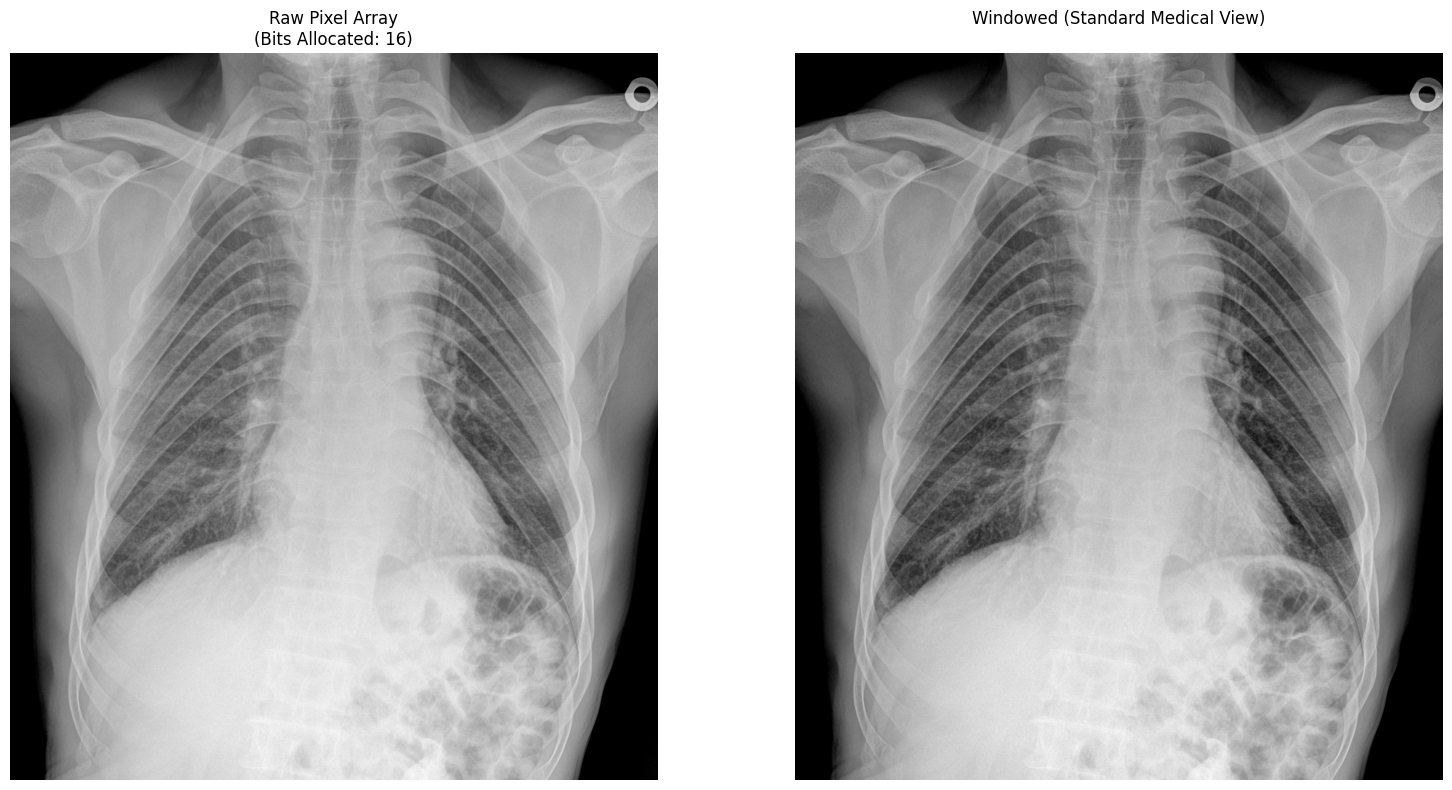

In [3]:
if analyzer.dataset:
    # Lấy ảnh không dùng Windowing (Gốc)
    img_raw, _ = analyzer.get_pixel_array(apply_windowing=False)
    
    # Lấy ảnh chuẩn y khoa (Đã áp dụng VOI LUT Windowing)
    img_windowed, is_inverted = analyzer.get_pixel_array(apply_windowing=True)
    
    if img_raw is not None and img_windowed is not None:
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        # Plot ảnh gốc chưa tinh chỉnh
        axes[0].imshow(img_raw, cmap="gray")
        axes[0].set_title(f"Raw Pixel Array\n(Bits Allocated: {meta.get('Bits Allocated')})")
        axes[0].axis("off")
        
        # Plot ảnh đã áp dụng Windowing
        inv_txt = "(Inverted MONOCHROME1)" if is_inverted else ""
        axes[1].imshow(img_windowed, cmap="gray")
        axes[1].set_title(f"Windowed (Standard Medical View)\n{inv_txt}")
        axes[1].axis("off")
        
        plt.tight_layout()
        plt.show()
    else:
        print("Không thể trích xuất hình ảnh từ DICOM.")


### 3. (Tùy chọn) In toàn bộ DICOM Tags
Nếu thông tin bệnh nhân ở bước 1 bị thiếu, bro chạy cell dưới đây để in toàn bộ các thẻ ẩn trong file. Có thể bệnh viện giấu tên bệnh nhân ở một thẻ (Tag) khác!

In [4]:
# Bỏ comment dòng dưới để xem toàn bộ 100+ thẻ DICOM có trong file
analyzer.print_all_tags()

(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ''
(0008,0016) SOP Class UID                       UI: Digital X-Ray Image Storage - For Presentation
(0008,0018) SOP Instance UID                    UI: 1.2.410.200018.109.1.100.54906.57961.100033.20260402050440000
(0008,0020) Study Date                          DA: '20260402'
(0008,0021) Series Date                         DA: '20260402'
(0008,0022) Acquisition Date                    DA: '20260402'
(0008,0023) Content Date                        DA: '20260402'
(0008,002A) Acquisition DateTime                DT: ''
(0008,0030) Study Time                          TM: '050440.000000'
(0008,0031) Series Time                         TM: '050440.000000'
(0008,0032) Acquisition Time                    TM: '050440.000000'
(0008,0033) Content Time                        TM: '050440.000000'
(0008,0050) Accession Number                    SH: '20260402001'
(0008,0060) Modality  